# Mesh Tutorial 7: Simulation Domains with DomainMesh

Boundary conditions determine the physics. Without them, a PDE isn't well-posed -
"solve Navier-Stokes on this mesh" is meaningless until you specify which walls are
no-slip, where the inflow is, and what the freestream velocity is.

The challenge is that interior and boundary data are **heterogeneous**:

- The **interior** is a triangulated volume or surface (`Mesh[2, 2]` or `Mesh[2, 3]`)
  carrying fields like pressure and velocity.
- Each **boundary** may be a different manifold dimension (`Mesh[1, 2]` curves,
  `Mesh[2, 3]` surfaces) with its own fields (wall shear, prescribed velocity).
- **Domain-level metadata** (Reynolds number, Mach number) applies globally.

`DomainMesh` groups these into a single tensorclass:

| Field | Type | Purpose |
|-------|------|----------|
| `interior` | `Mesh` | Volume mesh, point cloud, or prediction surface |
| `boundaries` | `dict[str, Mesh]` | Named boundary patches keyed by BC type |
| `global_data` | `dict[str, Tensor]` | Domain-level quantities (Re, Mach, etc.) |

Operations like rotation, scaling, and validation propagate automatically -
the interior, all boundaries, and their attached data move together.

---

## Why DomainMesh?

Production pipelines like GLOBE already need this pattern. DrivAerML manually
assembles a `prediction_mesh`, a `boundary_meshes: TensorDict[str, Mesh]` dict,
and separate `global_data` - then passes them around as loose fields. Every new
model reimplements this bundling.

`DomainMesh` standardizes it at a **model-agnostic** level: not prescriptive in
how you use boundary info in your model, only in how you represent it. Key features:

- **`apply_to_meshes(fn)`**: Apply any `Mesh -> Mesh` function to all meshes at once
- **Geometric transforms**: `translate`, `rotate`, `scale` with optional vector-field
  co-rotation - enabling on-the-fly data augmentation for quasi-equivariance
- **Serialization**: Saves/loads like a `Mesh`, with a directory structure that
  allows on-disk surgery on individual components
- **Validation**: Aggregate quality checks across the entire domain

In this tutorial we'll build a `DomainMesh` from a real CFD sample -
a 2D flow simulation around a cylinder.

## What You'll Learn

1. Load a real CFD domain with PyVista (interior + boundary meshes)
2. Project 3D simulation data to 2D and assemble into a `DomainMesh`
3. Inspect domain properties and iterate over meshes
4. Use geometric transforms for data augmentation (quasi-equivariance)
5. Validate mesh quality across the domain
6. Visualize the pressure field around the cylinder

In [1]:
import pyvista as pv
import torch

from physicsnemo.mesh import DomainMesh, Mesh
from physicsnemo.mesh.io import from_pyvista
from physicsnemo.mesh.projections import project

## Section 1: Loading a Real CFD Domain

PyVista provides a [small, public cylinder-crossflow CFD sample](https://docs.pyvista.org/api/examples/_autosummary/pyvista.examples.downloads.download_cylinder_crossflow.html)
with a 2D simulation domain split
into an interior mesh and named boundary patches:

| Block | Contents | Target type |
|------|----------|-------------|
| `fluid` | Flow field with pressure, velocity, and vorticity | `Mesh[2, 2]` |
| `wall_cylinder` | Cylinder surface (no-slip wall) | `Mesh[1, 2]` |
| inlet/outlet patches | Outer domain boundary | `Mesh[1, 2]` |

The dataset is downloaded and cached by PyVista. Its coordinates and vector fields
are stored in 3D with a constant z-coordinate, so we
use `project(keep_dims=[0, 1])` to drop the z-axis and get proper 2D meshes.
This is the same loading pattern used for VTK output from many CFD solvers.

In [2]:
case = pv.examples.download_cylinder_crossflow()

# Interior: triangulated flow field -> Mesh[2, 2]
# transform_point_data=True projects vector fields (e.g. velocity) alongside coordinates
raw_interior = project(
    from_pyvista(case["fluid"]),
    keep_dims=[0, 1],
    transform_point_data=True,
)

# Keep only the physics fields
interior = Mesh(
    points=raw_interior.points,
    cells=raw_interior.cells,
    point_data=raw_interior.point_data.select("pressure", "velocity", "vorticity_mag"),
)
print(f"Interior:\n\n{interior}")

Interior:

Mesh[n_manifold_dims=2, n_spatial_dims=2](n_points=14831, n_cells=29149)
    point_data: {pressure: (), velocity: (2,), vorticity_mag: ()}


In [3]:
# Cylinder boundary (no-slip wall) -> Mesh[1, 2]
# transform_point_data=True projects velocity from 3D to 2D
cylinder_patch = case["wall_cylinder"].extract_surface(algorithm=None)
raw_cylinder = project(
    from_pyvista(cylinder_patch, manifold_dim=1),
    keep_dims=[0, 1],
    transform_point_data=True,
)
cylinder = Mesh(
    points=raw_cylinder.points,
    cells=raw_cylinder.cells,
    point_data=raw_cylinder.point_data.select("pressure", "velocity", "vorticity_mag"),
)
print(f"Cylinder:\n\n{cylinder}")

Cylinder:

Mesh[n_manifold_dims=1, n_spatial_dims=2](n_points=63, n_cells=63)
    point_data: {pressure: (), velocity: (2,), vorticity_mag: ()}


In [4]:
# Combine the inlet and outlet patches into one far-field boundary -> Mesh[1, 2]
farfield_patches = pv.merge(
    [case[name] for name in ("inlet", "outlet", "outlet_top", "outlet_bottom")]
)
farfield_surface = farfield_patches.extract_surface(algorithm=None)
raw_freestream = project(
    from_pyvista(farfield_surface, manifold_dim=1),
    keep_dims=[0, 1],
    transform_point_data=True,
)
freestream = Mesh(
    points=raw_freestream.points,
    cells=raw_freestream.cells,
    point_data=raw_freestream.point_data.select(
        "pressure", "velocity", "vorticity_mag"
    ),
)
print(f"Freestream:\n\n{freestream}")

Freestream:

Mesh[n_manifold_dims=1, n_spatial_dims=2](n_points=450, n_cells=450)
    point_data: {pressure: (), velocity: (2,), vorticity_mag: ()}


### Assembling the Domain

The two boundary meshes represent the physical boundary conditions:

- **Cylinder** (no-slip wall): the solid body where velocity is zero
- **Freestream** (far-field): the outer domain boundary at the edge of the computational domain

Each boundary is represented independently and can carry its own physics fields.
Here both carry `pressure`, `velocity`, and `vorticity_mag`; in production, patches
can differ. The interior is a `Mesh[2, 2]` triangulation while the boundaries
are `Mesh[1, 2]` curves, each with data appropriate to its role.

Domain-level quantities like the freestream velocity vector `U_inf` go in `global_data`.

In [5]:
U_inf = torch.from_numpy(case["inlet"].point_data["velocity"][0, :2])
dm = DomainMesh(
    interior=interior,
    boundaries={
        "cylinder": cylinder,
        "freestream": freestream,
    },
    global_data={"U_inf": U_inf},
)

print(dm)

DomainMesh(
    interior: Mesh[n_manifold_dims=2, n_spatial_dims=2](n_points=14831, n_cells=29149)
        point_data: {pressure: (), velocity: (2,), vorticity_mag: ()}
    boundaries:
        cylinder  : Mesh[n_manifold_dims=1, n_spatial_dims=2](n_points=63, n_cells=63)
            point_data: {pressure: (), velocity: (2,), vorticity_mag: ()}
        freestream: Mesh[n_manifold_dims=1, n_spatial_dims=2](n_points=450, n_cells=450)
            point_data: {pressure: (), velocity: (2,), vorticity_mag: ()}
    global_data: {U_inf: (2,)}
)


## Section 2: Inspecting the Domain

A `DomainMesh` provides properties and iterators for exploring its contents.

In [6]:
# Access individual boundaries by name
print(f"{dm.boundaries['cylinder'] = }")

# Access domain-level metadata
U_inf = dm.global_data["U_inf"]
print(f"U_inf = {U_inf}  (|U_inf| = {U_inf.norm():.2f} native units)")

dm.boundaries['cylinder'] = Mesh[n_manifold_dims=1, n_spatial_dims=2](n_points=63, n_cells=63)
    point_data: {pressure: (), velocity: (2,), vorticity_mag: ()}
U_inf = tensor([35.,  0.])  (|U_inf| = 35.00 native units)


In [7]:
# Iterate over all meshes: interior first, then boundaries in sorted order
for name, mesh in dm:
    print(f"{name}:\n{mesh}\n")

interior:
Mesh[n_manifold_dims=2, n_spatial_dims=2](n_points=14831, n_cells=29149)
    point_data: {pressure: (), velocity: (2,), vorticity_mag: ()}

cylinder:
Mesh[n_manifold_dims=1, n_spatial_dims=2](n_points=63, n_cells=63)
    point_data: {pressure: (), velocity: (2,), vorticity_mag: ()}

freestream:
Mesh[n_manifold_dims=1, n_spatial_dims=2](n_points=450, n_cells=450)
    point_data: {pressure: (), velocity: (2,), vorticity_mag: ()}



## Section 3: Data Augmentation via Geometric Transforms

For non-equivariant model architectures (like GeoTransolver), a practical way to
improve generalization is **data augmentation**: present the same physical problem
at different orientations during training. This requires rotating or translating the
entire domain - geometry, boundary conditions, and vector-valued data - consistently.

`DomainMesh` makes this a one-liner. All transform methods (`translate`, `rotate`,
`scale`, `transform`) propagate to the interior and every boundary mesh.
To co-rotate vector fields with the geometry, pass a dict specifying which fields
are spatial vectors (e.g. `transform_point_data={"velocity": True}`).

In [8]:
# Rotate the entire domain by 0.5 radians,
# co-rotating velocity fields and the freestream vector
dm_rotated = dm.rotate(
    angle=0.5,
    transform_point_data={"velocity": True},
    transform_global_data={"U_inf": True},
)

# Both geometry and vector data were rotated together
print("Freestream velocity (U_inf):")
print(f"  Original: {dm.global_data['U_inf']}")
print(f"  Rotated:  {dm_rotated.global_data['U_inf']}")
print()
print("Interior velocity at point 0:")
print(f"  Original: {dm.interior.point_data['velocity'][0]}")
print(f"  Rotated:  {dm_rotated.interior.point_data['velocity'][0]}")

Freestream velocity (U_inf):
  Original: tensor([35.,  0.])
  Rotated:  tensor([30.7154, 16.7799])

Interior velocity at point 0:
  Original: tensor([ 3.5008e+01, -9.0405e-03])
  Rotated:  tensor([30.7267, 16.7758])


In [9]:
# Fluent chaining: apply multiple transforms in one expression
dm_transformed = dm.translate([1.0, 0.0]).rotate(angle=0.2).scale(2.0)

# All meshes moved together
for name, mesh in dm_transformed:
    centroid = mesh.points.mean(dim=0)
    print(f"  {name:12s}: centroid = [{centroid[0]:.2f}, {centroid[1]:.2f}]")

  interior    : centroid = [14.92, 3.02]
  cylinder    : centroid = [6.86, 1.39]
  freestream  : centroid = [16.66, 3.38]


## Section 4: Validation

`DomainMesh.validate()` runs mesh quality checks on the interior and every boundary,
aggregating results into a single domain-level report.

In [10]:
report = dm.validate()
print(f"Domain valid: {report['valid']}")
print(f"  Interior:    {report['interior']['valid']}")
if not report["interior"]["valid"]:
    print(f"    degenerate cells: {report['interior']['n_degenerate_cells']}")
for name, bc_report in report["boundaries"].items():
    print(f"  {name:12s}: {bc_report['valid']}")

Domain valid: True
  Interior:    True
  cylinder    : True
  freestream  : True


The interior and boundary meshes validate cleanly.

## Section 5: Visualization

`DomainMesh.draw()` draws the interior mesh with optional scalar coloring and
overlays all boundary curves automatically. It returns the canvas (a
matplotlib `Axes` or PyVista `Plotter`), so you can set axis limits afterwards
to zoom into a subregion around the cylinder.

The EnSight files do not include unit metadata, so these figures label coordinates
and fields in the dataset's native units.

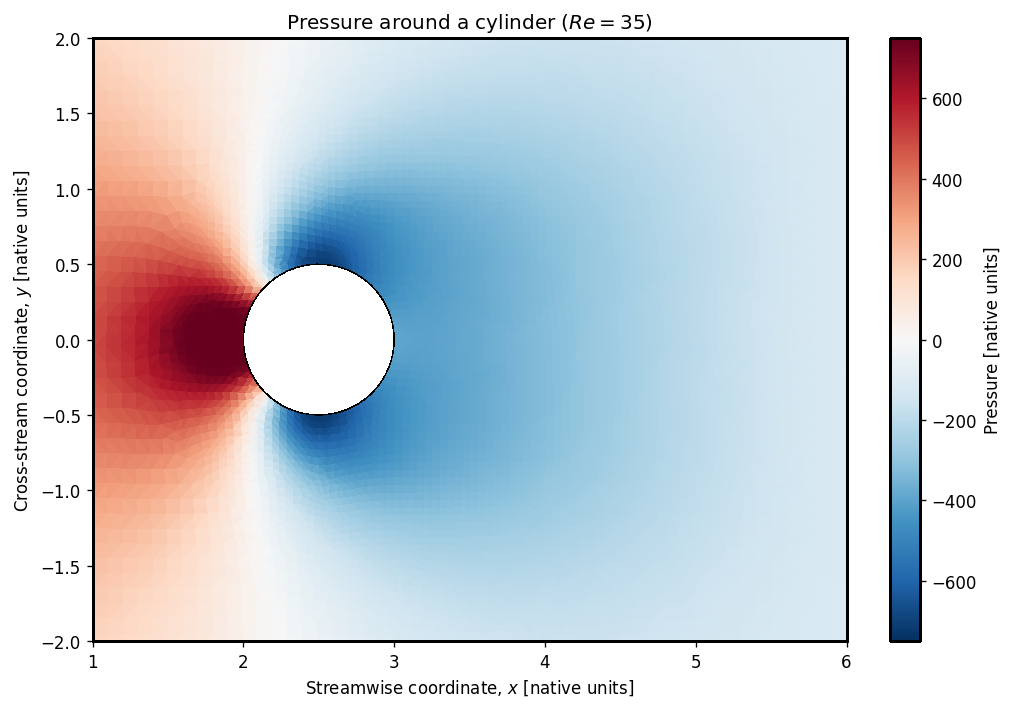

In [11]:
import matplotlib as mpl
import matplotlib.pyplot as plt

# Suppress hairline seams between adjacent filled polygons and render crisply
plot_style = {"patch.antialiased": False, "figure.dpi": 120}
pressure_limit = 750.0
boundary_style = {"show_edges": True}

with plt.rc_context(plot_style):
    fig, ax = plt.subplots(figsize=(8.4, 5.8), layout="constrained")
    dm.draw(
        point_scalars="pressure",
        cmap="RdBu_r",
        vmin=-pressure_limit,
        vmax=pressure_limit,
        backend="matplotlib",
        boundary_kwargs=boundary_style,
        ax=ax,
        show=False,
    )
    ax.set(
        xlim=(1, 6),
        ylim=(-2, 2),
        xlabel="Streamwise coordinate, $x$ [native units]",
        ylabel="Cross-stream coordinate, $y$ [native units]",
        title="Pressure around a cylinder ($Re=35$)",
    )
    fig.axes[-1].set_ylabel("Pressure [native units]")
    plt.show()

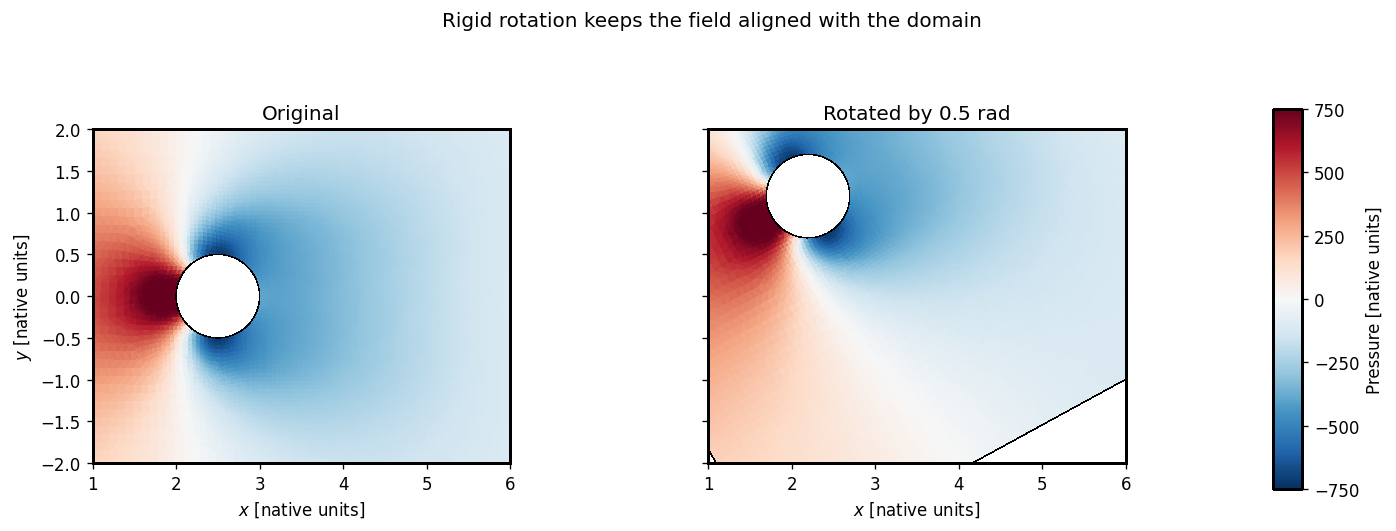

In [12]:
# Compare the original and rotated domains on one shared pressure scale
with plt.rc_context(plot_style):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4.8), sharex=True, sharey=True)
    domains = (dm, dm_rotated)
    titles = ("Original", "Rotated by 0.5 rad")

    for ax, domain, title in zip(axes, domains, titles, strict=True):
        domain.draw(
            point_scalars="pressure",
            cmap="RdBu_r",
            vmin=-pressure_limit,
            vmax=pressure_limit,
            backend="matplotlib",
            boundary_kwargs=boundary_style,
            ax=ax,
            show=False,
        )
        # DomainMesh.draw adds a colorbar; replace both with one shared scale.
        fig.axes[-1].remove()
        ax.set(
            xlim=(1, 6),
            ylim=(-2, 2),
            xlabel="$x$ [native units]",
            title=title,
        )

    axes[0].set_ylabel("$y$ [native units]")
    axes[1].set_ylabel("")
    fig.subplots_adjust(left=0.07, right=0.86, bottom=0.13, top=0.84, wspace=0.18)
    colorbar_ax = fig.add_axes([0.89, 0.15, 0.02, 0.66])
    scalar_mappable = mpl.cm.ScalarMappable(
        norm=mpl.colors.Normalize(-pressure_limit, pressure_limit),
        cmap="RdBu_r",
    )
    fig.colorbar(
        scalar_mappable,
        cax=colorbar_ax,
        label="Pressure [native units]",
        ticks=[-750, -500, -250, 0, 250, 500, 750],
    )
    fig.suptitle("Rigid rotation keeps the field aligned with the domain")
    plt.show()

## Section 6: Spatial Queries

The `physicsnemo.mesh.sampling` module provides spatial query primitives:

- `match_points(source, target, tolerance)` - find coincident vertices
  between two point sets (KNN + tolerance filter)
- `knn(points, queries, k)` - k-nearest neighbor search

These compose naturally with `DomainMesh` for tasks like computing wall
distance or scattering boundary data onto the interior.

Cylinder vertices matched to interior: 63 / 63


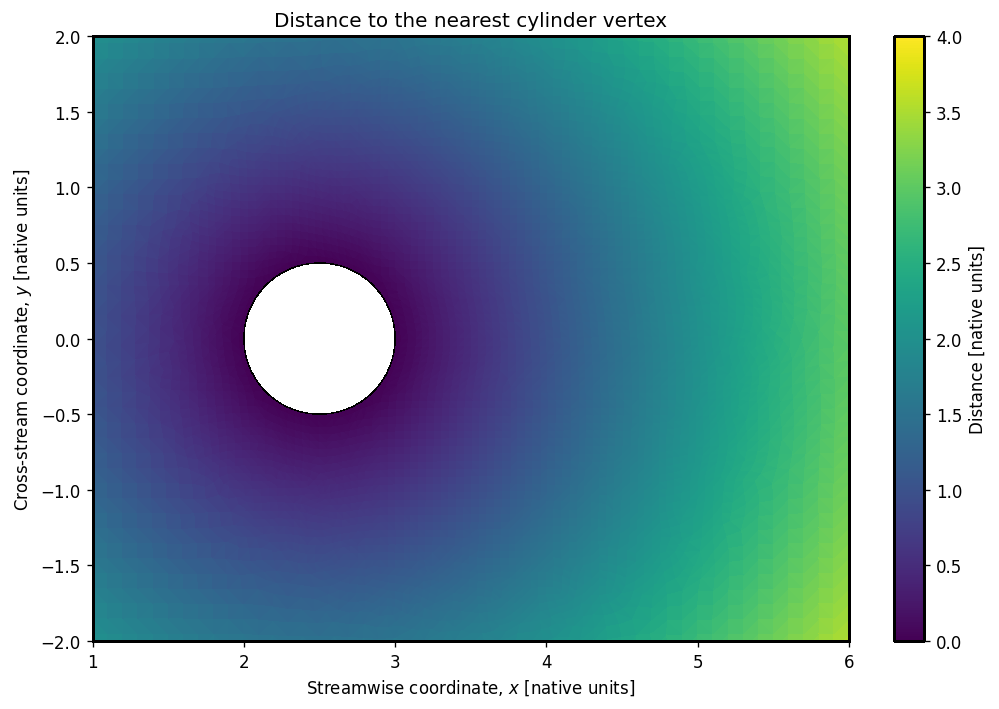

In [13]:
# Match the cylinder boundary vertices to vertices in the interior mesh
from physicsnemo.mesh.sampling import match_points
from physicsnemo.nn.functional.neighbors import knn

src_idx, tgt_idx = match_points(
    dm.boundaries["cylinder"].points,
    dm.interior.points,
    tolerance=1e-6,
)
print(
    f"Cylinder vertices matched to interior: {len(src_idx)} / {dm.boundaries['cylinder'].n_points}"
)

# Wall distance via KNN: nearest cylinder vertex for each interior point
cylinder_pts = dm.boundaries["cylinder"].points
_, dist = knn(points=cylinder_pts, queries=dm.interior.points, k=1)
dm.interior.point_data["wall_distance"] = dist[:, 0]

with plt.rc_context(plot_style):
    fig, ax = plt.subplots(figsize=(8.4, 5.8), layout="constrained")
    dm.draw(
        point_scalars="wall_distance",
        cmap="viridis",
        vmin=0,
        vmax=4,
        backend="matplotlib",
        boundary_kwargs=boundary_style,
        ax=ax,
        show=False,
    )
    ax.set(
        xlim=(1, 6),
        ylim=(-2, 2),
        xlabel="Streamwise coordinate, $x$ [native units]",
        ylabel="Cross-stream coordinate, $y$ [native units]",
        title="Distance to the nearest cylinder vertex",
    )
    fig.axes[-1].set_ylabel("Distance [native units]")
    plt.show()

## Summary

`DomainMesh` provides a standardized representation for simulation domains:

- **Three fields**: `interior` (the mesh), `boundaries` (named BC patches),
  `global_data` (domain parameters)
- **`draw()`**: One-line visualization with interior scalar coloring and boundary
  overlays; zoom by setting axis limits on the returned canvas
- **`apply_to_meshes(fn)`**: Map any `Mesh -> Mesh` function over the entire domain; all
  built-in operations delegate here
- **Spatial queries**: `match_points` and `knn` compose with `DomainMesh`
  for wall distance, data scattering, and other cross-component operations
- **Data augmentation**: Geometric transforms with explicit field selection
  (e.g. `transform_point_data={"velocity": True}`) co-rotate vector fields for
  quasi-equivariance
- **Validation**: `validate()` aggregates quality checks; `is_boundary_watertight()`
  verifies boundary patches tile into a closed surface

This is the foundation for standardized PDE problem representations, enabling
reusable datapipes that work across datasets and model architectures.